In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2pvbmF0aGFuL2FyZWFzL3dlYnNpdGVfcGVyc29uYWwvd2Vic2l0ZS9yZXBvLy53b3JrdHJlZXMvdGFsZW50LXZzLWx1Y2svcG9zdHMvMjAxOC0wMy0xMi10YWxlbnQtdnMtbHVjay1wYXJ0LTE='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/importlib/_bootstrap.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/importlib/_bootstrap_external.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/zipimport.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/codecs.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/encodings/aliases.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/encodings/__init__.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/encodings/utf_8.py": 1770141207.0, "/usr/local/Cellar/python@3.13/3.13.12_1/Frameworks/Python.

In [2]:
#| label: setup
#| code-summary: Imports and parameters
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

rng = np.random.default_rng(seed=20180312)

# Paper's parameters
N_PEOPLE = 1000
N_TIMESTEPS = 80
STARTING_CAPITAL = 10.0
TALENT_MEAN = 0.6
TALENT_SD = 0.1
P_LUCKY = 0.5

# Our estimate of p_event (derived in appendix)
P_EVENT = 0.16

In [3]:
#| label: simulation
#| code-summary: Vectorized TvL simulation
def run_tvl_simulation(n_people=N_PEOPLE, n_timesteps=N_TIMESTEPS,
                       starting_capital=STARTING_CAPITAL,
                       talent_mean=TALENT_MEAN, talent_sd=TALENT_SD,
                       p_event=P_EVENT, p_lucky=P_LUCKY, rng=rng):
    """Run the TvL simulation; returns (talent array, final_capital array)."""
    talent = np.clip(rng.normal(talent_mean, talent_sd, n_people), 0, 1)

    # Pre-draw all random numbers: shape (n_people, n_timesteps)
    event_roll   = rng.random((n_people, n_timesteps))
    lucky_roll   = rng.random((n_people, n_timesteps))
    capital_roll = rng.random((n_people, n_timesteps))

    event_happens = event_roll < p_event
    is_lucky      = lucky_roll < p_lucky
    capitalizes   = capital_roll < talent[:, np.newaxis]

    # multiplier per (person, timestep)
    multiplier = np.where(
        event_happens & is_lucky & capitalizes, 2.0,
        np.where(event_happens & ~is_lucky, 0.5, 1.0)
    )

    final_capital = starting_capital * multiplier.prod(axis=1)
    return talent, final_capital

talent, final_capital = run_tvl_simulation()
print(f"Median final capital:  {np.median(final_capital):.3f}")
print(f"Mean final capital:    {np.mean(final_capital):.3f}")
print(f"Max final capital:     {np.max(final_capital):.1f}")
print(f"Fraction who grew:     {(final_capital > STARTING_CAPITAL).mean():.1%}")

Median final capital:  1.250
Mean final capital:    26.164
Max final capital:     5120.0
Fraction who grew:     17.4%


In [4]:
#| label: tvl-probabilities
#| code-summary: Analytical per-timestep probabilities
def tvl_probabilities(quantile, talent_mean=TALENT_MEAN, talent_sd=TALENT_SD,
                      p_event=P_EVENT, p_lucky=P_LUCKY):
    """Return (p_halve, p_same, p_double) for a person at a given talent quantile."""
    p_halve  = p_event * (1.0 - p_lucky)
    talent   = np.clip(ss.norm.ppf(quantile, loc=talent_mean, scale=talent_sd), 0, 1)
    p_double = p_event * p_lucky * talent
    p_same   = 1.0 - p_halve - p_double
    return p_halve, p_same, p_double

# Compare extremes
for q, label in [(0.05, "5th percentile"), (0.50, "50th percentile"), (0.95, "95th percentile")]:
    ph, ps, pd = tvl_probabilities(q)
    print(f"{label:20s}  p_double={pd:.4f}  p_same={ps:.4f}  p_halve={ph:.4f}")

ph_95, _, pd_95 = tvl_probabilities(0.95)
ph_05, _, pd_05 = tvl_probabilities(0.05)
print(f"\nDifference in p_double (95th − 5th): {pd_95 - pd_05:.4f}  ({(pd_95 - pd_05)*100:.2f} pp)")

5th percentile        p_double=0.0348  p_same=0.8852  p_halve=0.0800
50th percentile       p_double=0.0480  p_same=0.8720  p_halve=0.0800
95th percentile       p_double=0.0612  p_same=0.8588  p_halve=0.0800

Difference in p_double (95th − 5th): 0.0263  (2.63 pp)


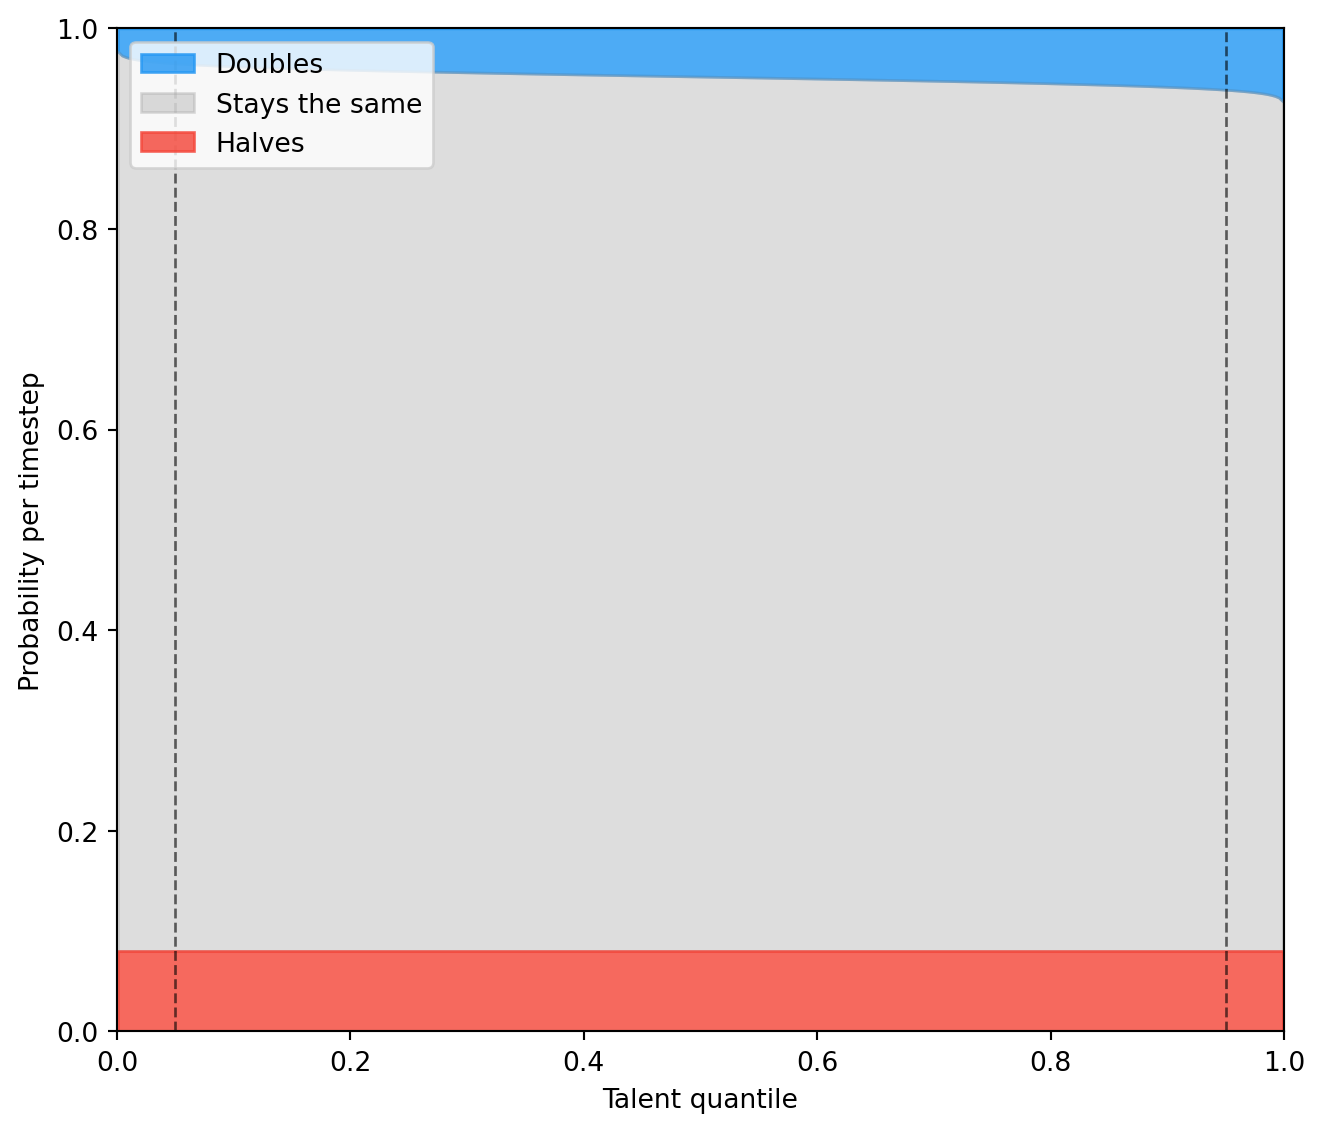

In [5]:
#| label: fig-probability-bands
#| fig-cap: Per-timestep outcome probabilities across all talent quantiles. The 5th and 95th percentiles are marked. The tiny difference in the blue 'doubles' band is the entire effect of talent in this model.
quantiles = np.linspace(0.001, 0.999, 300)
probs = np.array([tvl_probabilities(q) for q in quantiles])
p_halve, p_same, p_double = probs[:, 0], probs[:, 1], probs[:, 2]

fig, ax = plt.subplots(figsize=(7, 6))
ax.fill_between(quantiles, p_halve + p_same, 1.0,   color="#2196F3", alpha=0.8, label="Doubles")
ax.fill_between(quantiles, p_halve,           p_halve + p_same, color="#9E9E9E", alpha=0.35, label="Stays the same")
ax.fill_between(quantiles, 0,                 p_halve,          color="#F44336", alpha=0.8, label="Halves")

for q in (0.05, 0.95):
    ax.axvline(q, color="black", lw=1.0, ls="--", alpha=0.6)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Talent quantile")
ax.set_ylabel("Probability per timestep")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
#| label: expected-value
#| code-summary: Expected value calculation
def expected_value(quantile, starting_capital=STARTING_CAPITAL, n_timesteps=N_TIMESTEPS):
    p_halve, p_same, p_double = tvl_probabilities(quantile)
    per_step_ev_multiplier = p_double * 2.0 + p_same * 1.0 + p_halve * 0.5
    return starting_capital * per_step_ev_multiplier ** n_timesteps

# Even the 99.999th percentile
for q, label in [(0.5, "50th"), (0.95, "95th"), (0.999, "99.9th"), (0.99999, "99.999th")]:
    ev = expected_value(q)
    print(f"{label:10s} percentile → expected final capital: {ev:.4f}  (started at {STARTING_CAPITAL})")

50th       percentile → expected final capital: 18.9166  (started at 10.0)
95th       percentile → expected final capital: 53.3905  (started at 10.0)
99.9th     percentile → expected final capital: 131.4224  (started at 10.0)
99.999th   percentile → expected final capital: 230.4980  (started at 10.0)


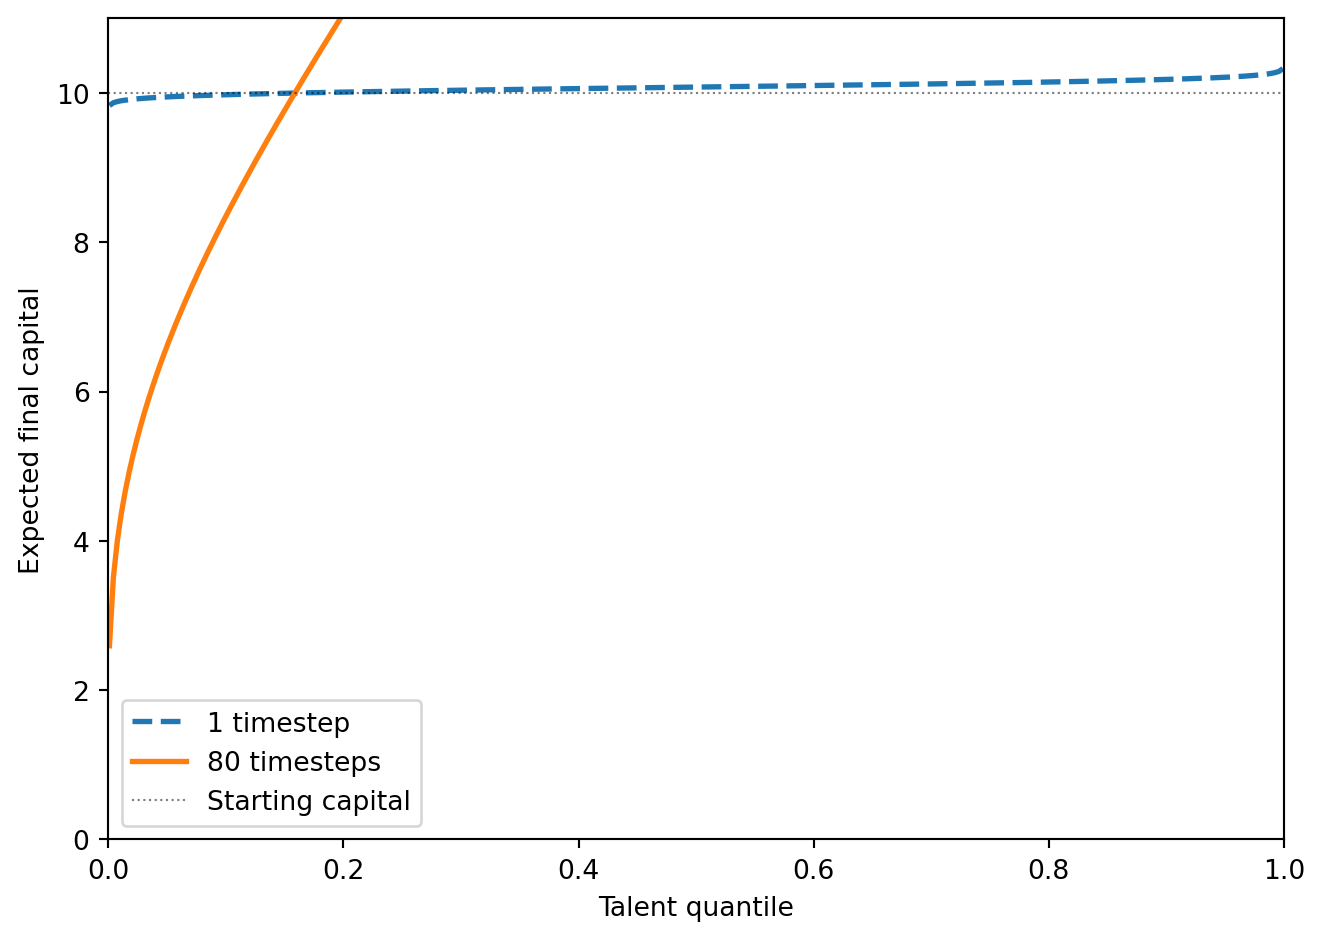

In [7]:
#| label: fig-expected-value
#| fig-cap: Expected final capital by talent quantile after 1 and 80 timesteps. Starting capital is 10 — both curves stay below that for all quantiles.
quantiles = np.linspace(0.001, 0.999, 300)

fig, ax = plt.subplots(figsize=(7, 5))
for t, ls in [(1, "--"), (80, "-")]:
    evs = [expected_value(q, n_timesteps=t) for q in quantiles]
    ax.plot(quantiles, evs, ls=ls, lw=2, label=f"{t} timestep{'s' if t > 1 else ''}")

ax.axhline(STARTING_CAPITAL, color="black", lw=0.8, ls=":", alpha=0.5, label="Starting capital")
ax.set_xlim(0, 1)
ax.set_ylim(0, STARTING_CAPITAL + 1)
ax.set_xlabel("Talent quantile")
ax.set_ylabel("Expected final capital")
ax.legend()
plt.tight_layout()
plt.show()

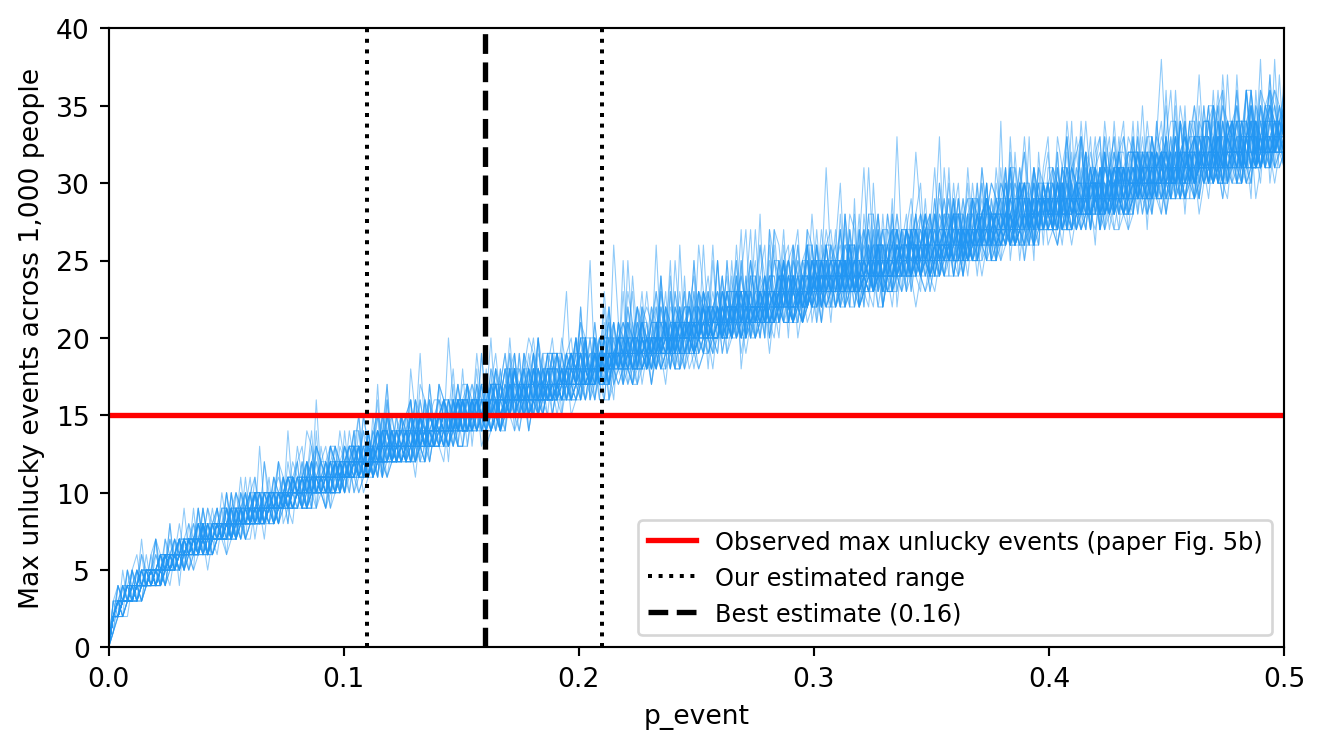

In [8]:
#| label: fig-p-event
#| code-summary: Estimating p_event from paper Figure 5b
#| fig-cap: Maximum unlucky events per person across 50 simulation trials, for different values of p_event. The paper's Figure 5b shows a maximum of ~15 unlucky events; our estimate of p_event=0.16 sits in the middle of the plausible range.
p_event_low      = 0.11
p_event_estimate = 0.16
p_event_high     = 0.21

p_events = np.linspace(0.0, 0.5, 250)
trial_rng = np.random.default_rng(seed=42)

fig, ax = plt.subplots(figsize=(7, 4))
for trial in range(50):
    max_unlucky = []
    for pe in p_events:
        n_events = (trial_rng.random((N_PEOPLE, N_TIMESTEPS)) < pe).sum(axis=1)
        n_lucky  = np.array([trial_rng.binomial(n, P_LUCKY) for n in n_events])
        max_unlucky.append((n_events - n_lucky).max())
    ax.plot(p_events, max_unlucky, lw=0.4, color="#2196F3", alpha=0.5)

ax.axhline(15, color="red", lw=2, label="Observed max unlucky events (paper Fig. 5b)")
ax.axvline(p_event_low,      color="black", lw=1.5, ls=":",  label="Our estimated range")
ax.axvline(p_event_high,     color="black", lw=1.5, ls=":")
ax.axvline(p_event_estimate, color="black", lw=2.0, ls="--", label="Best estimate (0.16)")
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 40)
ax.set_xlabel("p_event")
ax.set_ylabel("Max unlucky events across 1,000 people")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()